## Guided Project v1

This is the simplest version of an object detector. After you are done understanding and playing with this, explore Next model [MiniYOLOv2]()

Like all machine learning projects, you need four things

1. Dataset: We will need MSCOCO dataset. I have already downloaded it for you to a google drive folder. Open [the link](https://drive.google.com/drive/folders/1TDWJC7wK7qxY7xcciMsFfESTYENBppfM?usp=sharing) and click down "miniCOCO" dropdown, then "Organize" and then "Add Shortcut". Navigate to the scratch directory created earlier and select "All Locations" > MyDrive,  click "New Folder" (name it scratch) and select scratch "Add" button. Check [your google drive](https://drive.google.com/drive/my-drive) to make sure that you have a `scratch` folder in the drive and `miniCOCO` inside it.

2. Model: Choosing machine Learning models (also called neural network atchitectures) are not hard science, they are improved by trial and error on different problems. If you are solving a new problem, you need to find which problem is the most similar to this problem and what models have been used for this problem. Here we are developing a small model of [YOLO26 from the Utralytics repository](https://github.com/ultralytics/ultralytics/blob/9294ae6b3063dbcf20a79b6355d378bef27321d1/ultralytics/cfg/models/26/yolo26.yaml).

3. Loss function: YOLO does not use a single loss but a combination of loss functions.

4. Optimizer: We are going to use a standard Adam optimizer.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import os
    os.chdir('/content/drive/MyDrive/scratch/miniCOCO')
except ImportError:
    pass
import os
COCO_ROOT_DIR = os.getcwd()

In [2]:
import urllib
import zipfile
import os
COCO_MINITRAIN_ZIP = os.path.join(COCO_ROOT_DIR,'coco_minitrain_25k.zip')
if not os.path.exists(COCO_MINITRAIN_ZIP):
    print("Downloading a huge dataset")
    urllib.request.urlretrieve('https://huggingface.co/datasets/bryanbocao/coco_minitrain/resolve/main/coco_minitrain_25k.zip',
                             filename=COCO_MINITRAIN_ZIP)
COCO_DATA_DIR = os.path.join(COCO_ROOT_DIR, 'coco_minitrain_25k')
if not os.path.exists(COCO_DATA_DIR):
  with zipfile.ZipFile(COCO_MINITRAIN_ZIP, 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
# The dataloader.py file might be for COCO JSON format. Removing it to avoid confusion with the new YOLO Dataset.
# cocodataloader = 'dataloader.py'
# if os.path.exists(cocodataloader):
#     os.remove(cocodataloader)


In [4]:
# COCO 80 class names in YOLO label order (0-indexed, matching class_id in .txt files)
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
    'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush',
]
print(f"{len(COCO_CLASSES)} COCO classes loaded")


80 COCO classes loaded


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import os
from PIL import Image

# --- 1. Tiny YOLO-like Model (Target ~10K Params) ---

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class TinyYOLO(nn.Module):
    def __init__(self, num_classes=2, img_size=416):
        super().__init__()
        self.img_size = img_size
        self.grid_size = img_size // 32
        self.num_classes = num_classes

        # Extremely slim backbone to keep parameters around 10k
        self.features = nn.Sequential(
            ConvBlock(3, 8, k=3, s=2),    # 416 -> 208
            ConvBlock(8, 16, k=3, s=2),   # 208 -> 104
            ConvBlock(16, 16, k=3, s=2),  # 104 -> 52
            ConvBlock(16, 16, k=3, s=2),  # 52 -> 26
            ConvBlock(16, 16, k=3, s=2),  # 26 -> 13
        )

        # Detection head: 1x1 conv to map to output dimension
        # Output: 1 anchor per cell for simplicity: (x, y, w, h, conf, class1, class2)
        self.output_dim = 1 * (5 + num_classes)
        self.head = nn.Conv2d(16, self.output_dim, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        # Reshape to [Batch, Grid, Grid, 5 + num_classes]
        x = x.permute(0, 2, 3, 1).contiguous()
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = TinyYOLO(num_classes=2)
print(f"Total trainable parameters: {count_parameters(model)}")


# --- 2. YOLO Loss: BCE for objectness/class, SmoothL1 for box regression ---

class YOLOLoss(nn.Module):
    """
    Composite YOLO loss:
      - Objectness  : BCEWithLogitsLoss (all cells, no-obj cells down-weighted by lambda_noobj)
      - Box (x,y,w,h): SmoothL1Loss    (obj cells only, up-weighted by lambda_coord)
      - Class probs : BCEWithLogitsLoss (obj cells only)

    Target layout per cell: [obj, x, y, w, h, c0, c1, ..., cN]
    """
    def __init__(self, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
        self.smooth_l1 = nn.SmoothL1Loss(reduction='none')

    def forward(self, preds, targets):
        # preds, targets: [B, G, G, 5+C]
        obj_mask = targets[..., 0] == 1   # [B, G, G]  True where an object center falls
        noobj_mask = ~obj_mask

        # Objectness loss: BCE on every cell
        conf_loss = self.bce(preds[..., 0], targets[..., 0])
        obj_conf_loss   = (obj_mask.float()   * conf_loss).sum()
        noobj_conf_loss = (noobj_mask.float() * conf_loss).sum()

        # Box regression (SmoothL1): only for cells that contain an object
        box_loss = self.smooth_l1(preds[..., 1:5], targets[..., 1:5])
        box_loss = (obj_mask.unsqueeze(-1).float() * box_loss).sum()

        # Class probabilities (BCE): only for cells that contain an object
        cls_loss = self.bce(preds[..., 5:], targets[..., 5:])
        cls_loss = (obj_mask.unsqueeze(-1).float() * cls_loss).sum()

        total_loss = (self.lambda_coord * box_loss
                      + obj_conf_loss
                      + self.lambda_noobj * noobj_conf_loss
                      + cls_loss)
        return total_loss


Total trainable parameters: 8543


In [6]:
import torch
import numpy as np
from PIL import Image
import os

class YOLODataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, set_name, img_size=256, grid_size=8, num_classes=2, transform=None, max_images=None):
        self.root_dir = root_dir
        self.set_name = set_name
        self.img_dir = os.path.join(root_dir, 'images', set_name)
        self.label_dir = os.path.join(root_dir, 'labels', set_name)
        self.img_size = img_size
        self.grid_size = grid_size
        self.num_classes = num_classes
        self.transform = transform

        all_image_files = [f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        all_image_files.sort() # Ensure consistent order

        if max_images is not None:
            self.image_files = all_image_files[:max_images]
        else:
            self.image_files = all_image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt'))

        # Load image
        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size))
        img = np.array(img).astype(np.float32) / 255.0 # Normalize to [0, 1]

        # Initialize target tensor for YOLO format (grid_size, grid_size, 5 + num_classes)
        # Each grid cell will store: [objectness, x_center_rel, y_center_rel, width_rel, height_rel, class_probs...]
        # x_center_rel, y_center_rel, width_rel, height_rel are relative to the grid cell.
        target = torch.zeros((self.grid_size, self.grid_size, 5 + self.num_classes))

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_c_norm, y_c_norm, w_norm, h_norm = map(float, parts[1:])

                    # Denormalize to image coordinates (pixels)
                    x_c_px = x_c_norm * self.img_size
                    y_c_px = y_c_norm * self.img_size

                    # Determine which grid cell the center of the object falls into
                    cell_x = int(self.grid_size * x_c_norm)
                    cell_y = int(self.grid_size * y_c_norm)

                    # Calculate box coordinates relative to the grid cell
                    grid_cell_size_px = self.img_size / self.grid_size
                    x_in_cell_px = x_c_px - (cell_x * grid_cell_size_px)
                    y_in_cell_px = y_c_px - (cell_y * grid_cell_size_px)

                    x_center_rel = x_in_cell_px / grid_cell_size_px # 0 to 1 within the cell
                    y_center_rel = y_in_cell_px / grid_cell_size_px # 0 to 1 within the cell

                    # Set objectness score to 1 and class probabilities
                    if cell_y < self.grid_size and cell_x < self.grid_size: # Ensure cell is within bounds
                        target[cell_y, cell_x, 0] = 1.0  # Objectness score
                        target[cell_y, cell_x, 1:5] = torch.tensor([x_center_rel, y_center_rel, w_norm, h_norm])
                        target[cell_y, cell_x, 5 + class_id] = 1.0 # One-hot encode class

        img = torch.from_numpy(img).permute(2, 0, 1) # Convert to C, H, W format

        if self.transform:
            img = self.transform(img)

        return img, target

In [7]:
# --- 3. Functional Training Setup ---
import shutil

IMG_SIZE = 256
GRID_SIZE = IMG_SIZE // 32  # For TinyYOLO, grid_size = 8
NUM_CLASSES = 80  # COCO has 80 classes. Adjust if your minitrain has fewer.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = YOLODataset(root_dir=COCO_DATA_DIR, set_name='train2017',
                      img_size=IMG_SIZE, grid_size=GRID_SIZE,
                      num_classes=NUM_CLASSES,
                      max_images=2000)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model = TinyYOLO(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Composite YOLO loss: BCE for objectness/classes, SmoothL1 for box coords
criterion = YOLOLoss(lambda_coord=5.0, lambda_noobj=0.5)

print(f"Loaded {len(dataset)} images")

# Run one batch to verify a single forward+backward pass works
images, targets = next(iter(dataloader))
images, targets = images.to(device), targets.to(device)

model.eval()
with torch.no_grad():
    preds = model(images)
    prev_loss = criterion(preds, targets)

model.train()
optimizer.zero_grad()
preds = model(images)
loss = criterion(preds, targets)
loss.backward()
optimizer.step()

print(f"Test batch loss: {loss.item():.4f} < {prev_loss.item():.4f} - Single iteration works!")


Loaded 2000 images
Test batch loss: 3837.4507 < 3670.4819 - Single iteration works!


In [8]:
# --- 4. Full Training Loop Implementation with File Logging ---
import csv

num_epochs = 5
log_file = 'training_log.csv'

# Initialize log file with headers
with open(log_file, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'val_loss'])

print(f"Starting training for {num_epochs} epochs on {device}...")

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    epoch_train_loss = 0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(dataloader)}], Train Loss: {loss.item():.4f}")

    avg_train_loss = epoch_train_loss / len(dataloader)

    # --- Validation Phase ---
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, targets in dataloader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(dataloader)

    # Log to CSV
    with open(log_file, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, avg_train_loss, avg_val_loss])

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"==> Epoch {epoch+1} Complete. Avg Train Loss: {avg_train_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}\n")

print(f"Training finished. Log saved to {log_file}")

Starting training for 5 epochs on cuda...
Epoch [1/5], Batch [100/250], Train Loss: 2033.1404
Epoch [1/5], Batch [200/250], Train Loss: 869.6570
==> Epoch 1 Complete. Avg Train Loss: 1318.3878, Avg Val Loss: 575.3255

Epoch [2/5], Batch [100/250], Train Loss: 805.8591
Epoch [2/5], Batch [200/250], Train Loss: 459.3846
==> Epoch 2 Complete. Avg Train Loss: 469.9828, Avg Val Loss: 391.3470

Epoch [3/5], Batch [100/250], Train Loss: 327.2348
Epoch [3/5], Batch [200/250], Train Loss: 272.5779
==> Epoch 3 Complete. Avg Train Loss: 368.4608, Avg Val Loss: 350.8646

Epoch [4/5], Batch [100/250], Train Loss: 316.7502
Epoch [4/5], Batch [200/250], Train Loss: 289.8298
==> Epoch 4 Complete. Avg Train Loss: 349.5050, Avg Val Loss: 344.3142

Epoch [5/5], Batch [100/250], Train Loss: 177.0172
Epoch [5/5], Batch [200/250], Train Loss: 271.9278
==> Epoch 5 Complete. Avg Train Loss: 342.9771, Avg Val Loss: 338.9044

Training finished. Log saved to training_log.csv


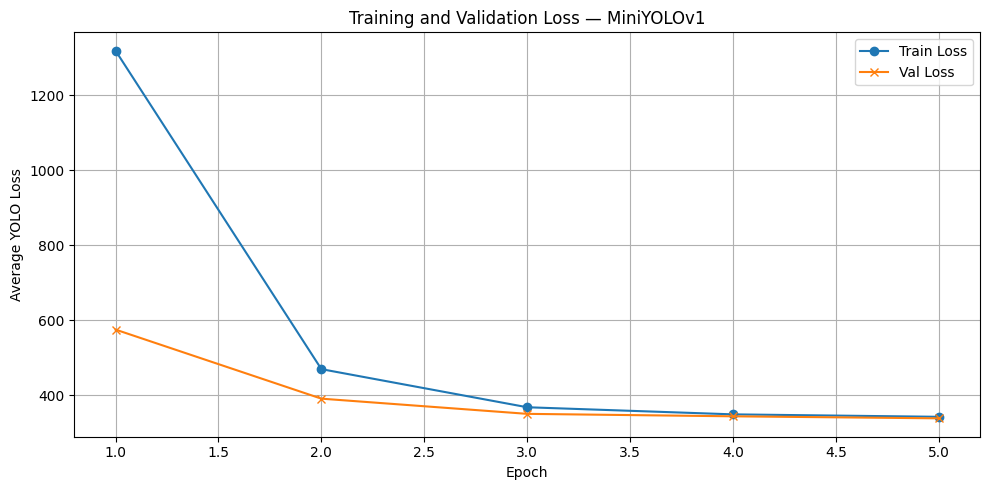

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Read losses from the log file
assert os.path.exists('training_log.csv'), \
    "Log file training_log.csv not found. Please run the training loop first."
df_log = np.loadtxt('training_log.csv', delimiter=',', skiprows=1)

plt.figure(figsize=(10, 5))
plt.plot(df_log[:, 0], df_log[:, 1], marker='o', label='Train Loss')
plt.plot(df_log[:, 0], df_log[:, 2], marker='x', label='Val Loss')

plt.title('Training and Validation Loss — MiniYOLOv1')
plt.xlabel('Epoch')
plt.ylabel('Average YOLO Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
import matplotlib.patches as patches
import matplotlib.patches as patches

def _cls_label(cls_id):
    """Return 'name (id)' or just 'cls id' if out of range."""
    if 0 <= cls_id < len(COCO_CLASSES):
        return COCO_CLASSES[cls_id]
    return f"cls {cls_id}"

def decode_boxes(pred, img_size, grid_size, conf_thresh=0.5):
    """Decode TinyYOLO output [G, G, 5+C] to pixel-space boxes.
    Returns list of (x1, y1, x2, y2, conf, class_id)."""
    cell_size = img_size / grid_size
    conf = torch.sigmoid(pred[..., 0])
    boxes = []
    for gy in range(grid_size):
        for gx in range(grid_size):
            c = conf[gy, gx].item()
            if c < conf_thresh:
                continue
            x_rel, y_rel, w_norm, h_norm = pred[gy, gx, 1:5].tolist()
            x_c = (gx + max(0.0, min(1.0, x_rel))) * cell_size
            y_c = (gy + max(0.0, min(1.0, y_rel))) * cell_size
            w, h = w_norm * img_size, h_norm * img_size
            x1, y1 = x_c - w / 2, y_c - h / 2
            class_id = int(torch.argmax(pred[gy, gx, 5:]).item())
            boxes.append((x1, y1, x1 + w, y1 + h, c, class_id))
    return boxes

def decode_gt_boxes(target, img_size, grid_size):
    """Decode ground-truth target tensor to pixel-space boxes."""
    cell_size = img_size / grid_size
    boxes = []
    for gy in range(grid_size):
        for gx in range(grid_size):
            if target[gy, gx, 0].item() != 1.0:
                continue
            x_rel, y_rel, w_norm, h_norm = target[gy, gx, 1:5].tolist()
            x_c = (gx + x_rel) * cell_size
            y_c = (gy + y_rel) * cell_size
            w, h = w_norm * img_size, h_norm * img_size
            x1, y1 = x_c - w / 2, y_c - h / 2
            class_id = int(torch.argmax(target[gy, gx, 5:]).item())
            boxes.append((x1, y1, x1 + w, y1 + h, class_id))
    return boxes

Sample 1: 0 raw detections → 0 after NMS
Sample 2: 20 raw detections → 20 after NMS
Sample 3: 1 raw detections → 1 after NMS


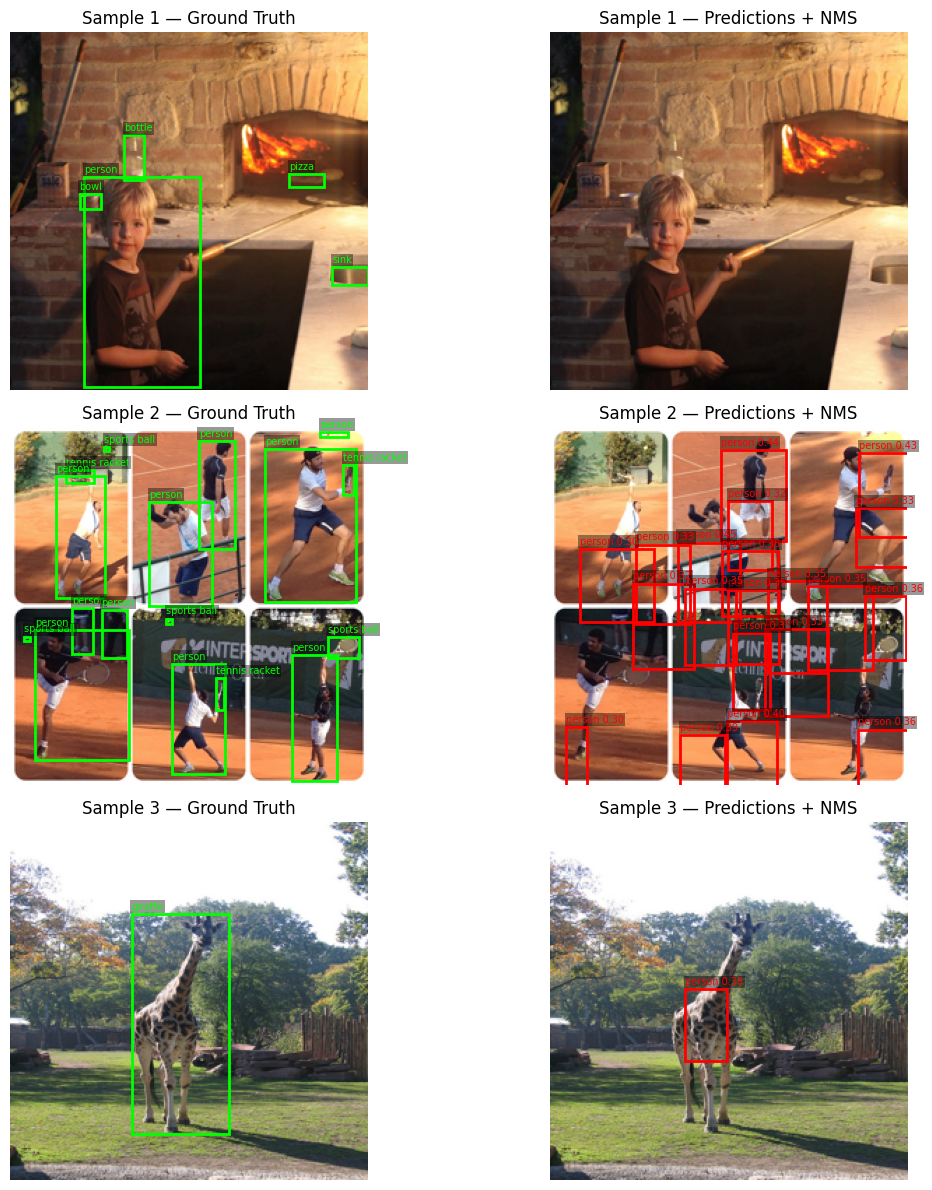

In [14]:
# --- 6. Non-Maximum Suppression (NMS) ---

def compute_iou(box1, box2):
    """Compute Intersection-over-Union for two boxes given as (x1, y1, x2, y2, ...)."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def nms(boxes, iou_thresh=0.45):
    """Non-Maximum Suppression over a list of decoded boxes.

    Args:
        boxes      : list of (x1, y1, x2, y2, conf, class_id)
        iou_thresh : boxes with IoU > this value are suppressed

    Returns:
        Filtered list of boxes, sorted by confidence descending.
    """
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda b: b[4], reverse=True)
    kept = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        # Keep only boxes whose IoU with 'best' is below the threshold
        boxes = [b for b in boxes if compute_iou(best, b) < iou_thresh]
    return kept


def visualize_samples_nms(model, dataloader, device,
                          num_samples=3, conf_thresh=0.3, iou_thresh=0.45):
    """Like visualize_samples but applies NMS to predictions before drawing."""
    model.eval()
    images, targets = next(iter(dataloader))
    images  = images[:num_samples]
    targets = targets[:num_samples]
    with torch.no_grad():
        preds_out = model(images.to(device)).cpu()

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        img_np = images[i].permute(1, 2, 0).numpy()
        sz = img_np.shape[1]

        raw_boxes = decode_boxes(preds_out[i], sz, GRID_SIZE, conf_thresh)
        nms_boxes = nms(raw_boxes, iou_thresh)

        print(f"Sample {i+1}: {len(raw_boxes)} raw detections → {len(nms_boxes)} after NMS")

        for col, (title, box_list, color) in enumerate([
            ("Ground Truth",          decode_gt_boxes(targets[i], sz, GRID_SIZE), "lime"),
            (f"Predictions + NMS",    nms_boxes,                                  "red"),
        ]):
            ax = axes[i][col]
            ax.imshow(img_np)
            ax.set_title(f"Sample {i+1} — {title}")
            ax.axis('off')

            if color == "lime":        # ground-truth branch: no conf field
                for (x1, y1, x2, y2, cls) in box_list:
                    ax.add_patch(patches.Rectangle(
                        (x1, y1), x2-x1, y2-y1, lw=2, edgecolor=color, facecolor='none'))
                    ax.text(x1, y1 - 3, _cls_label(cls), color=color, fontsize=7,
                            bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))
            else:                       # prediction branch: has conf field
                for (x1, y1, x2, y2, conf, cls) in box_list:
                    ax.add_patch(patches.Rectangle(
                        (x1, y1), x2-x1, y2-y1, lw=2, edgecolor=color, facecolor='none'))
                    ax.text(x1, y1 - 3, f"{_cls_label(cls)} {conf:.2f}",
                            color=color, fontsize=7,
                            bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

    plt.tight_layout()
    plt.show()


visualize_samples_nms(model, dataloader, device,
                      num_samples=3, conf_thresh=0.3, iou_thresh=0.45)
